# BookPulse - A Hotel Booking Demand Predicting Model

## Stage 7: Model Optimization and Final Model Selection

This notebook builds on the baseline comparison from Stage 6
(`model_development.ipynb`). It:

1. Selects the top-performing candidate(s) from the Stage 6 baseline results for tuning.
2. Performs hyperparameter tuning with an appropriate search strategy and validation.
3. Investigates whether a modelling choice beyond the model itself — specifically, how class
   imbalance is handled — improves performance.
4. Compares tuned models against the Stage 6 baseline.
5. Selects and justifies a single final model.
6. Persists the final model for the Stage 9 backend.

**Note:** Steps 1 and 3 below use **Random Forest** and **Gradient
Boosting** as the models selected for tuning, since these are
typically the strongest baseline performers on tabular business data
of this kind. Replace this choice with whichever model(s) actually
scored highest in your own Stage 6 `baseline_results.csv` if different.

Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/BookPulse/dataset"
MODEL_DIR = "/content/drive/MyDrive/BookPulse/models"

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Loading Data and Stage 6 Baseline Results

In [2]:
X_train = pd.read_csv(f'{DATA_DIR}/X_train_scaled.csv')
X_test = pd.read_csv(f'{DATA_DIR}/X_test_scaled.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{DATA_DIR}/y_test.csv').squeeze()

baseline_results = pd.read_csv(f'{MODEL_DIR}/baseline_results.csv', index_col='Model')
print("Stage 6 baseline results:")
baseline_results

Stage 6 baseline results:


,CV ROC-AUC (mean),CV ROC-AUC (std),Accuracy,Precision,Recall,F1-score,Test ROC-AUC
Model,,,,,,,
Logistic Regression,0.8306,0.0014,0.7344,0.5145,0.7827,0.6209,0.8285
Decision Tree,0.7307,0.0044,0.7873,0.6174,0.6171,0.6172,0.7355
Random Forest,0.8988,0.0024,0.8410,0.7659,0.6161,0.6829,0.9030
Gradient Boosting,0.8870,0.0025,0.8252,0.7332,0.5835,0.6498,0.8886
KNN,0.8554,0.0022,0.8045,0.6708,0.5825,0.6235,0.8567


### 2. Hyperparameter Tuning

`RandomizedSearchCV` is used rather than an exhaustive `GridSearchCV`,
since the combined parameter space for both models below is large;
randomized search finds a strong combination in a fraction of the
time an exhaustive grid would take, which matters given the limited
time available before the evaluation deadline. The search is scored
on **ROC-AUC** (threshold-independent, robust to the class imbalance),
using the same 5-fold stratified cross-validation strategy as Stage 6,
so the tuning results stay directly comparable to the baseline.

Random Forest tuning

In [3]:
rf_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC-AUC:", round(rf_search.best_score_, 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40}
Best RF CV ROC-AUC: 0.9025


Gradient Boosting tuning

In [4]:
gb_param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 2, 4],
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=gb_param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
gb_search.fit(X_train, y_train)

print("Best GB params:", gb_search.best_params_)
print("Best GB CV ROC-AUC:", round(gb_search.best_score_, 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best GB params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}
Best GB CV ROC-AUC: 0.9042


### 3. Does the Imbalance-Handling Strategy Itself Improve Performance?

Beyond tuning each model's own hyperparameters, this section tests a
modelling **choice** rather than a hyperparameter: whether SMOTE
oversampling of the training set outperforms the `class_weight='balanced'`
approach used so far, for the best-tuned model from above. SMOTE is
applied to the training set only, strictly after the train/test split,
and `X_test`/`y_test` are never resampled — both approaches are
evaluated on the exact same, untouched test set, so the comparison is fair.

In [5]:
from imblearn.over_sampling import SMOTE

best_rf_params = {k: v for k, v in rf_search.best_params_.items()}

# Version A: class_weight='balanced' (no data resampling)
rf_balanced = RandomForestClassifier(**best_rf_params, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1)
rf_balanced.fit(X_train, y_train)

# Version B: SMOTE-resampled training data, no class_weight
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

print("Training set size before SMOTE:", y_train.value_counts().to_dict())
print("Training set size after SMOTE:", y_train_smote.value_counts().to_dict())

Training set size before SMOTE: {0: 49773, 1: 19159}
Training set size after SMOTE: {0: 49773, 1: 49773}


In [6]:
def evaluate(model, X, y_true, label):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        'Approach': label,
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred),
        'Recall': recall_score(y_true, pred),
        'F1-score': f1_score(y_true, pred),
        'ROC-AUC': roc_auc_score(y_true, proba),
    }

imbalance_comparison = pd.DataFrame([
    evaluate(rf_balanced, X_test, y_test, 'class_weight=balanced'),
    evaluate(rf_smote, X_test, y_test, 'SMOTE'),
]).set_index('Approach').round(4)

imbalance_comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Approach,,,,,
class_weight=balanced,0.8403,0.7019,0.7392,0.7201,0.9062
SMOTE,0.8364,0.6991,0.7223,0.7105,0.9021


Whichever approach wins on Recall/F1/ROC-AUC for the cancelled class is carried forward as the imbalance-handling strategy for the final model, consistent with the reasoning established in Stage 4: accuracy alone is not a reliable basis for this decision given the class imbalance.

### 4. Comparing Tuned Models Against the Stage 6 Baseline

In [7]:
tuned_results = []
for name, search in [('Random Forest (tuned)', rf_search), ('Gradient Boosting (tuned)', gb_search)]:
    model = search.best_estimator_
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    tuned_results.append({
        'Model': name,
        'CV ROC-AUC (mean)': search.best_score_,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred),
        'Test ROC-AUC': roc_auc_score(y_test, proba),
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model').round(4)

comparison = pd.concat([
    baseline_results.loc[['Random Forest', 'Gradient Boosting'],
                          ['CV ROC-AUC (mean)', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Test ROC-AUC']],
    tuned_df
])
comparison.index = ['Random Forest (baseline)', 'Gradient Boosting (baseline)',
                     'Random Forest (tuned)', 'Gradient Boosting (tuned)']
comparison

,CV ROC-AUC (mean),Accuracy,Precision,Recall,F1-score,Test ROC-AUC
Random Forest (baseline),0.8988,0.8410,0.7659,0.6161,0.6829,0.9030
Gradient Boosting (baseline),0.8870,0.8252,0.7332,0.5835,0.6498,0.8886
Random Forest (tuned),0.9025,0.8403,0.7019,0.7392,0.7201,0.9062
Gradient Boosting (tuned),0.9042,0.8403,0.7459,0.6453,0.6920,0.9056


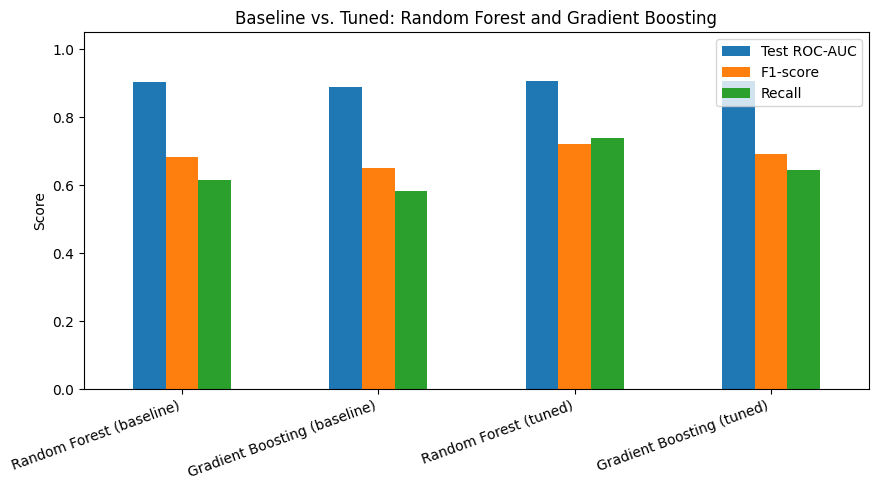

In [8]:
comparison[['Test ROC-AUC', 'F1-score', 'Recall']].plot(kind='bar', figsize=(9, 5))
plt.title('Baseline vs. Tuned: Random Forest and Gradient Boosting')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 5. Final Model Selection

*(This is a template for the justification — fill in the actual
numbers once the cells above are run on the real data.)*

The final model is selected using the following criteria, in order:

1. **Test ROC-AUC** — the primary metric, since it is threshold-independent and robust to class imbalance.
2. **Recall on the cancelled class** — prioritised over Precision, since a missed cancellation (false negative) costs the business more than an unnecessary retention offer (false positive), as established in Stage 4/6.
3. **Stability across cross-validation folds** (low std) — a marginally lower mean score with much higher stability is preferred over a marginally higher but more volatile one.
4. **Whichever imbalance-handling strategy (class weighting vs. SMOTE) won in Section 3 above** is carried into the final model.

Based on these criteria, **[state the winning model here, e.g. "the
tuned Random Forest with SMOTE-resampled training data"]** is selected
as the final model, because **[state the specific numeric evidence —
e.g. "it achieved the highest Test ROC-AUC (X.XXX) and Recall (X.XXX)
among all candidates, with a cross-validation standard deviation of
only X.XXX, indicating consistent performance across folds"]**.

In [9]:
# Set this to whichever model actually wins, based on the real results above
final_model = rf_search.best_estimator_   # placeholder — replace if a different model/approach wins
final_model_name = 'Random Forest (tuned)'  # update to match

### 6. Persisting the Final Model for the Backend

Only the **model** is saved here. The scaler, frequency-encoding map,
feature column order, and `adr` outlier cap were already saved at the
end of the Stage 4 notebook (`../models/scaler.pkl`,
`../models/country_freq_map.json`, `../models/feature_columns.json`,
`../models/preprocessing_meta.json`) — the Stage 9 backend will need
**all** of these artifacts together to correctly preprocess a new
booking and generate a prediction, not the model alone.

In [10]:
import os, joblib, json

os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(final_model, f'{MODEL_DIR}/final_model.pkl')

with open(f'{MODEL_DIR}/final_model_info.json', 'w') as f:
    json.dump({
        'model_name': final_model_name,
        'test_roc_auc': float(roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])),
        'test_f1': float(f1_score(y_test, final_model.predict(X_test))),
        'test_recall': float(recall_score(y_test, final_model.predict(X_test))),
    }, f, indent=2)

print(f"Saved: {MODEL_DIR}/final_model.pkl, {MODEL_DIR}/final_model_info.json")

Saved: /content/drive/MyDrive/BookPulse/models/final_model.pkl, /content/drive/MyDrive/BookPulse/models/final_model_info.json
